In [15]:
import pandas as pd, numpy as np
tr = pd.read_csv("IPH2026001_train_var1.csv")
te = pd.read_csv("IPH2026001_test_var1.csv")
print(tr.shape, te.shape)
print(tr.head())
print(tr.describe())

(1000, 7) (1000, 6)
         x1        x2        x3        x4        x5        x6         y
0 -0.032511  0.355030  0.363189 -1.000000  1.000000  1.000000  5.337793
1 -0.933064 -0.718637 -1.000000 -1.000000 -1.000000 -0.582772  0.435361
2  0.610016 -0.504131 -0.223279  0.310369  0.673773  0.517820 -1.227551
3  0.951665 -0.234587  1.000000  0.291367 -0.065149 -0.808531  3.513747
4 -0.187584  0.096880 -0.061798 -0.440186  1.000000  0.742293  2.737282
                x1           x2           x3           x4           x5  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000   
mean      0.007205    -0.018134    -0.003461    -0.006026    -0.040900   
std       0.718387     0.705123     0.708726     0.716788     0.705388   
min      -1.000000    -1.000000    -1.000000    -1.000000    -1.000000   
25%      -0.695100    -0.682070    -0.670399    -0.668424    -0.708706   
50%      -0.012448    -0.034875     0.013120     0.014535    -0.068899   
75%       0.687894     0.60642

In [16]:
from sklearn.model_selection import train_test_split
X = tr[["x1","x2","x3","x4","x5","x6"]].values
y = tr["y"].values
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

degrees = range(1, 8)
train_err, val_err = [], []
for d in degrees:
    model = make_pipeline(PolynomialFeatures(d), StandardScaler(), LinearRegression())
    model.fit(X_tr, y_tr)
    train_err.append(mean_squared_error(y_tr, model.predict(X_tr)))
    val_err.append(mean_squared_error(y_val, model.predict(X_val)))

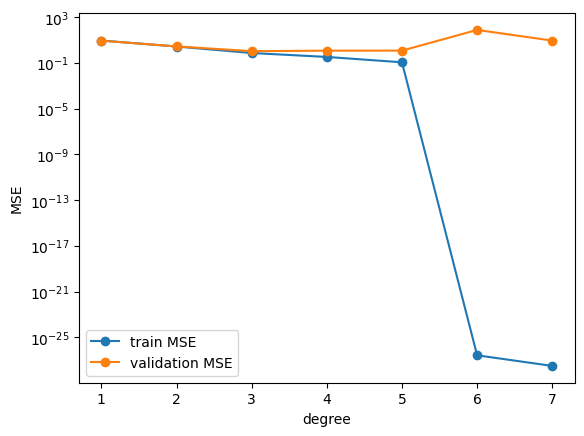

In [18]:
import matplotlib.pyplot as plt
plt.plot(degrees, train_err, "o-", label="train MSE")
plt.plot(degrees, val_err, "o-", label="validation MSE")
plt.yscale("log"); plt.xlabel("degree"); plt.ylabel("MSE"); plt.legend()
plt.show()

In [19]:
from sklearn.model_selection import cross_val_score
for d in degrees:
    model = make_pipeline(PolynomialFeatures(d), StandardScaler(), LinearRegression())
    scores = cross_val_score(model, X, y, cv=5, scoring="neg_mean_squared_error")
    print(d, -scores.mean())

1 9.105017398569432
2 2.890083482254544
3 0.9905538733065485
4 0.750867406071477
5 1.420993165336383
6 68.02696158737119
7 6.089521778911917


In [20]:
X3 = tr[["x1","x2","x3"]].values

In [21]:
best_degree = 4
final = make_pipeline(PolynomialFeatures(best_degree), StandardScaler(), LinearRegression())
final.fit(X, y)
pred = final.predict(te[["x1","x2","x3","x4","x5","x6"]].values)
pd.DataFrame({"y": pred}).to_csv("IPH2026001_pred_var1.csv", index=False)

 degree  parameters (dof)  train MSE  val MSE  CV MSE
      1                 7     9.0740   8.7046  9.1050
      2                28     2.7192   2.7820  2.8901
      3                84     0.7345   1.0625  0.9906
      4               210     0.3329   1.1796  0.7509
      5               462     0.1133   1.1855  1.4210
      6               924     0.0000  76.8842 68.0270
Lowest CV MSE at degree 4


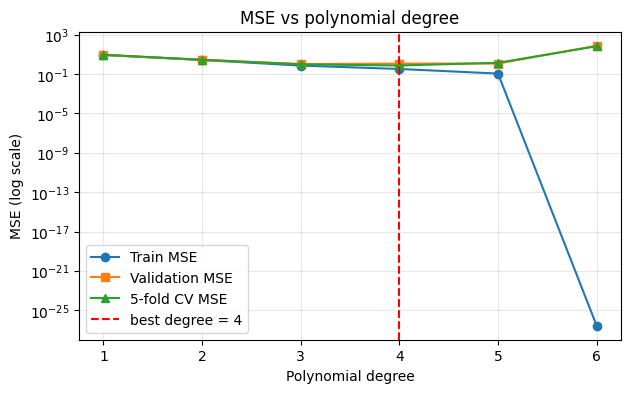

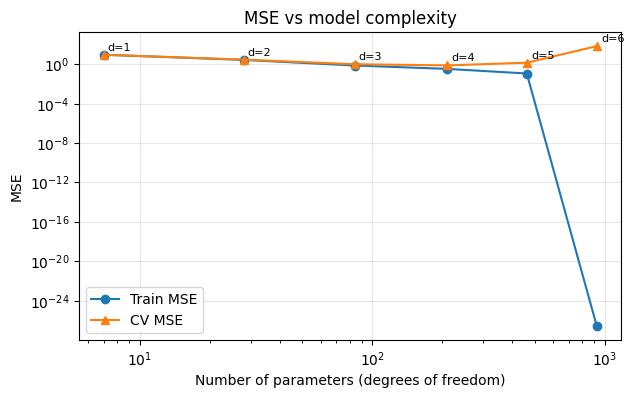

In [22]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from math import comb
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score

# ---- settings: change these for each problem ----
file = "IPH2026001_train_var1.csv"            # or ..._train_var2.csv
features = ["x1","x2","x3","x4","x5","x6"]    # var2: ["x1","x2","x3"]
max_degree = 6                                # var1: ~6, var2: ~12

tr = pd.read_csv(file)
X, y = tr[features].values, tr["y"].values
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

n = len(features)
degrees = list(range(1, max_degree + 1))
dof = [comb(n + d, d) for d in degrees]       # number of parameters at each degree

train_mse, val_mse, cv_mse = [], [], []
for d in degrees:
    model = make_pipeline(PolynomialFeatures(d), StandardScaler(), LinearRegression())
    model.fit(X_tr, y_tr)
    train_mse.append(np.mean((model.predict(X_tr) - y_tr) ** 2))
    val_mse.append(np.mean((model.predict(X_val) - y_val) ** 2))
    s = cross_val_score(model, X, y, cv=5, scoring="neg_mean_squared_error")
    cv_mse.append(-s.mean())

# ---- table ----
results = pd.DataFrame({"degree": degrees, "parameters (dof)": dof,
                        "train MSE": train_mse, "val MSE": val_mse, "CV MSE": cv_mse})
print(results.round(4).to_string(index=False))
best = degrees[int(np.argmin(cv_mse))]
print("Lowest CV MSE at degree", best)

# ---- plot 1: MSE vs degree ----
plt.figure(figsize=(7,4))
plt.plot(degrees, train_mse, "o-", label="Train MSE")
plt.plot(degrees, val_mse, "s-", label="Validation MSE")
plt.plot(degrees, cv_mse, "^-", label="5-fold CV MSE")
plt.axvline(best, color="r", ls="--", label=f"best degree = {best}")
plt.yscale("log"); plt.xlabel("Polynomial degree"); plt.ylabel("MSE (log scale)")
plt.title("MSE vs polynomial degree"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

# ---- plot 2: MSE vs number of parameters ----
plt.figure(figsize=(7,4))
plt.plot(dof, train_mse, "o-", label="Train MSE")
plt.plot(dof, cv_mse, "^-", label="CV MSE")
for d, p, e in zip(degrees, dof, cv_mse):
    plt.annotate(f"d={d}", (p, e), fontsize=8, xytext=(3,3), textcoords="offset points")
plt.xscale("log"); plt.yscale("log")
plt.xlabel("Number of parameters (degrees of freedom)"); plt.ylabel("MSE")
plt.title("MSE vs model complexity"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

 degree  parameters (dof)  train MSE  val MSE  CV MSE
      1                 4    36.0933  36.7427 36.6671
      2                10    21.0996  22.1606 21.9963
      3                20    10.6813  13.4158 11.7215
      4                35     3.1666   4.1160  3.7139
      5                56     1.2656   1.3364  1.5460
      6                84     0.4182   0.6603  0.5750
      7               120     0.2407   0.2929  0.3478
      8               165     0.1788   0.2979  0.2996
      9               220     0.1598   0.3086  0.3387
     10               286     0.1406   0.3310  0.3958
     11               364     0.1222   0.5048  0.9453
     12               455     0.0973   1.3819  1.7450
Lowest CV MSE at degree 8


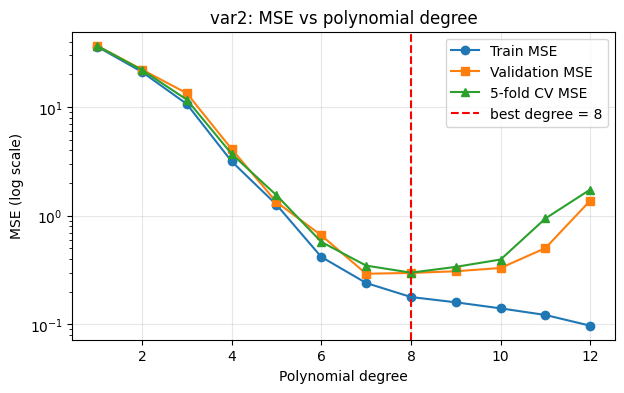

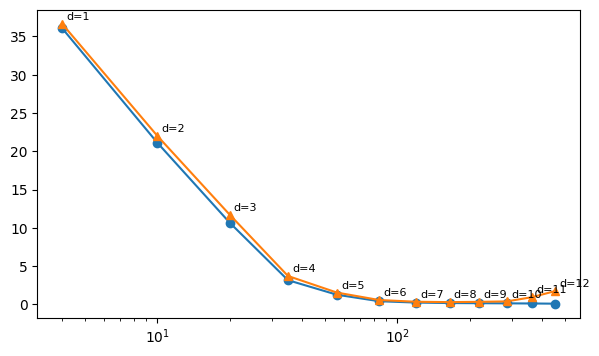

In [23]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from math import comb
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score

# ---------- load var2 ----------
tr = pd.read_csv("IPH2026001_train_var2.csv")
features = ["x1", "x2", "x3"]
max_degree = 12

X, y = tr[features].values, tr["y"].values
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

n = len(features)
degrees = list(range(1, max_degree + 1))
dof = [comb(n + d, d) for d in degrees]   # parameters at each degree (3 features)

train_mse, val_mse, cv_mse = [], [], []
for d in degrees:
    model = make_pipeline(PolynomialFeatures(d), StandardScaler(), LinearRegression())
    model.fit(X_tr, y_tr)
    train_mse.append(np.mean((model.predict(X_tr) - y_tr) ** 2))
    val_mse.append(np.mean((model.predict(X_val) - y_val) ** 2))
    s = cross_val_score(model, X, y, cv=5, scoring="neg_mean_squared_error")
    cv_mse.append(-s.mean())

results = pd.DataFrame({"degree": degrees, "parameters (dof)": dof,
                        "train MSE": train_mse, "val MSE": val_mse, "CV MSE": cv_mse})
print(results.round(4).to_string(index=False))
best = degrees[int(np.argmin(cv_mse))]
print("Lowest CV MSE at degree", best)

# ---------- plot 1: MSE vs degree ----------
plt.figure(figsize=(7, 4))
plt.plot(degrees, train_mse, "o-", label="Train MSE")
plt.plot(degrees, val_mse, "s-", label="Validation MSE")
plt.plot(degrees, cv_mse, "^-", label="5-fold CV MSE")
plt.axvline(best, color="r", ls="--", label=f"best degree = {best}")
plt.yscale("log"); plt.xlabel("Polynomial degree"); plt.ylabel("MSE (log scale)")
plt.title("var2: MSE vs polynomial degree"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

# ---------- plot 2: MSE vs number of parameters ----------
plt.figure(figsize=(7, 4))
plt.plot(dof, train_mse, "o-", label="Train MSE")
plt.plot(dof, cv_mse, "^-", label="CV MSE")
for d, p, e in zip(degrees, dof, cv_mse):
    plt.annotate(f"d={d}", (p, e), fontsize=8, xytext=(3, 3), textcoords="offset points")
plt.xscale("log");

In [24]:
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

features = ["x1", "x2", "x3"]
best_degree = 8          # from your CV plot

tr = pd.read_csv("IPH2026001_train_var2.csv")
te = pd.read_csv("IPH2026001_test_var2.csv")

# fit on ALL the training data (not just the 80% split)
final = make_pipeline(PolynomialFeatures(best_degree), StandardScaler(), LinearRegression())
final.fit(tr[features].values, tr["y"].values)

# predict the test set, keeping the same row order
pred = final.predict(te[features].values)
out = pd.DataFrame({"y": pred})
out.to_csv("IPH2026001_pred_var2.csv", index=False)

# sanity checks
print(out.shape, te.shape)       # both should have 1000 rows
print(out.isna().sum().sum())    # should be 0
print(out.describe())

(1000, 1) (1000, 3)
0
                 y
count  1000.000000
mean      2.017012
std       6.559550
min     -29.383332
25%      -0.710144
50%       1.190761
75%       4.761386
max      37.795328


var1: R² vs polynomial degree
 degree  train R2  val R2   CV R2
      1    0.1307  0.1396  0.1182
      2    0.7395  0.7250  0.7173
      3    0.9296  0.8950  0.9038
      4    0.9681  0.8834  0.9273
      5    0.9891  0.8828  0.8612
      6    1.0000 -6.5996 -5.8153
Highest CV R2 at degree 4 



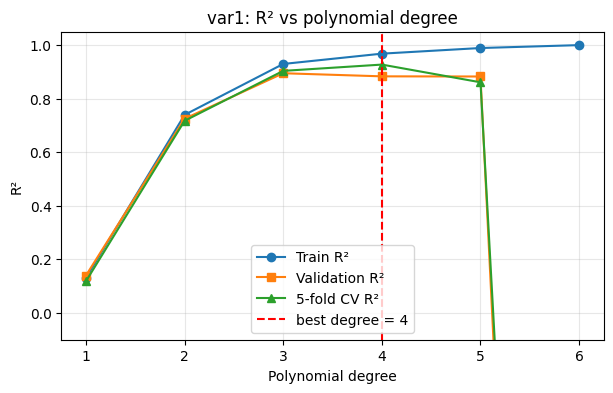

var2: R² vs polynomial degree
 degree  train R2  val R2  CV R2
      1    0.2971  0.2523 0.2697
      2    0.5891  0.5490 0.5559
      3    0.7920  0.7270 0.7640
      4    0.9383  0.9162 0.9247
      5    0.9754  0.9728 0.9684
      6    0.9919  0.9866 0.9880
      7    0.9953  0.9940 0.9928
      8    0.9965  0.9939 0.9938
      9    0.9969  0.9937 0.9930
     10    0.9973  0.9933 0.9918
     11    0.9976  0.9897 0.9816
     12    0.9981  0.9719 0.9662
Highest CV R2 at degree 8 



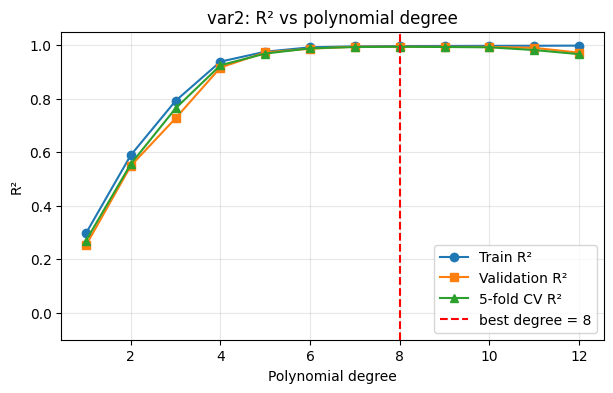

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score

def r2_plot(file, features, max_degree, title):
    tr = pd.read_csv(file)
    X, y = tr[features].values, tr["y"].values
    X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    degrees = list(range(1, max_degree + 1))
    train_r2, val_r2, cv_r2 = [], [], []
    for d in degrees:
        m = make_pipeline(PolynomialFeatures(d), StandardScaler(), LinearRegression())
        m.fit(X_tr, y_tr)
        train_r2.append(r2_score(y_tr, m.predict(X_tr)))
        val_r2.append(r2_score(y_val, m.predict(X_val)))
        cv_r2.append(cross_val_score(m, X, y, cv=5, scoring="r2").mean())
    print(title)
    print(pd.DataFrame({"degree": degrees, "train R2": train_r2,
                        "val R2": val_r2, "CV R2": cv_r2}).round(4).to_string(index=False))
    best = degrees[int(np.argmax(cv_r2))]
    print("Highest CV R2 at degree", best, "\n")
    plt.figure(figsize=(7, 4))
    plt.plot(degrees, train_r2, "o-", label="Train R²")
    plt.plot(degrees, val_r2, "s-", label="Validation R²")
    plt.plot(degrees, cv_r2, "^-", label="5-fold CV R²")
    plt.axvline(best, color="r", ls="--", label=f"best degree = {best}")
    plt.ylim(-0.1, 1.05)          # caps the axis so degree 6 on var1 doesn't squash the plot
    plt.xlabel("Polynomial degree"); plt.ylabel("R²")
    plt.title(title); plt.legend(); plt.grid(alpha=0.3)
    plt.show()

r2_plot("IPH2026001_train_var1.csv", ["x1","x2","x3","x4","x5","x6"], 6,  "var1: R² vs polynomial degree")
r2_plot("IPH2026001_train_var2.csv", ["x1","x2","x3"],               12, "var2: R² vs polynomial degree")